In [1]:
%matplotlib inline
import os
import re
import itertools
from itertools import combinations
import glob
import pickle
import argparse
import gzip

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import multiprocess as mp
import numpy as np
import pandas as pd
import bioframe as bf
import cooltools
import cooler
from matplotlib import gridspec
from matplotlib.gridspec import GridSpec
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
from collections import OrderedDict
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from matplotlib.ticker import EngFormatter

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/cooltools/lib/numutils.py:651: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit  # (nopython=True)
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/cooltools/lib/numutils.py:726: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit  # (nopython=True)


# calculate cis/total of bulk Hi-C

In [96]:
#load cooler.matrix files

#get 1Mb matrix
#set path and condition of five stages
pathcool = "/home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk"
conditions = [
    'ES',
    'DE',  
    'HB',
    'iHep',
    'mHep',
]

#binsize =1000000
#binsize =250000
binsize =50000

cooler_paths = { 
    'ES' : '{}/ESC-DdeI-DpnII-R1R2.hg38.mapq_30.1000.mcool::resolutions/{}'.format(pathcool,binsize),
    'DE' : '{}/DE-DdeI-DpnII-R1R2.hg38.mapq_30.1000.mcool::resolutions/{}'.format(pathcool,binsize),
    'HB' : '{}/HB-DdeI-DpnII-R1R2.hg38.mapq_30.1000.mcool::resolutions/{}'.format(pathcool,binsize),
    'iHep' : '{}/iHEP-DdeI-DpnII-R1R2.hg38.mapq_30.1000.mcool::resolutions/{}'.format(pathcool,binsize),
    'mHep' : '{}/mHEP-DdeI-DpnII-R1R2.hg38.mapq_30.1000.mcool::resolutions/{}'.format(pathcool,binsize),
}

long_names = { 
    'ES' : 'ES_rep12',
    'DE' : 'DE_rep12',  
    'HB' : 'HB_rep12',
    'iHep' : 'iHep_rep12',
    'mHep' : 'mHep_rep12',
}

clrs = {
    cond: cooler.Cooler(cooler_paths[cond]) for cond in conditions
}

samplePlotNames = {
    'ES' : 'ES',
    'DE' : 'DE',  
    'HB' : 'HB',
    'iHep' : 'iHep',
    'mHep' : 'mHep',
}

In [97]:
#check the matrix
clrs['ES'].matrix(balance=False)[5:10, 5:10]

array([[ 88882,   8826,   2414,   2203,   1498],
       [  8826,  58208,   6226,   3263,   1554],
       [  2414,   6226, 107308,  17904,   3849],
       [  2203,   3263,  17904, 105661,  20974],
       [  1498,   1554,   3849,  20974, 113569]], dtype=int32)

In [98]:
#check the index information
clrs['ES'].bins()[5:10]

,chrom,start,end,weight
5,chr1,1250000,1500000,0.003220
6,chr1,1500000,1750000,NaN
7,chr1,1750000,2000000,0.002571
8,chr1,2000000,2250000,0.002670
9,chr1,2250000,2500000,0.002566


In [99]:
#set function to remove diagnal
def zero_diagonal(matrix, n_diags=1):
    """
    Set diagonal and n off-diagonals of a square matrix to zero.
    
    Parameters:
    - matrix: 2D NumPy array (square)
    - n_diags: how many diagonals to zero out (1 = main diag only)
    
    Returns:
    - matrix with specified diagonals set to 0
    """
    mat = matrix.copy()
    for k in range(-n_diags + 1, n_diags):  # e.g., k = -1, 0, +1 for n_diags=2
        i, j = np.diag_indices_from(mat)
        if k < 0:
            i = i[-k:]
            j = j[:k]
        elif k > 0:
            i = i[:-k]
            j = j[k:]
        # k == 0 is the main diagonal
        mat[i, j] = 0
    return mat

In [100]:
#save all matrix and their index into new one dataframe
cooler_matrix = {}
cooler_matrix_removediagonal = {}
organize_df = {}

for cond in conditions:
    mat = clrs[cond].matrix(balance=False)[:]
    cooler_matrix[cond] = mat
    cooler_matrix_removediagonal[cond] = zero_diagonal(mat, n_diags=1)
    organize_df[cond] = clrs[cond].bins()[:][['chrom', 'start', 'end']]

In [101]:
#check the diagnol removed matrix
cooler_matrix_removediagonal[cond][5:10, 5:10]

array([[    0,  5723,  1061,   812,   357],
       [ 5723,     0,  3638,  1538,   511],
       [ 1061,  3638,     0, 10374,  1536],
       [  812,  1538, 10374,     0, 10909],
       [  357,   511,  1536, 10909,     0]], dtype=int32)

In [102]:
#count the cis_counts and trans_counts and total_counts
for cond in conditions:
    mat = cooler_matrix[cond]
    mat_rmdiagnal = cooler_matrix_removediagonal[cond]
    
    bins_df = clrs[cond].bins()[:][['chrom', 'start', 'end']].reset_index(drop=True)
    organize_df[cond] = bins_df.copy()

    # Prepare arrays
    cis_counts = np.zeros(len(bins_df))
    total_counts = np.zeros(len(bins_df))
    cis_counts_rmdiag = np.zeros(len(bins_df))
    total_counts_rmdiag = np.zeros(len(bins_df))

    for chrom in bins_df['chrom'].unique():
        chrom_bins = bins_df[bins_df['chrom'] == chrom]
        start_idx = chrom_bins.index.min()
        end_idx = chrom_bins.index.max() + 1

        # Full matrix
        cis_counts[start_idx:end_idx] = mat[start_idx:end_idx, start_idx:end_idx].sum(axis=0)
        total_counts[start_idx:end_idx] = mat[:, start_idx:end_idx].sum(axis=0)

        # Diagonal-removed matrix
        cis_counts_rmdiag[start_idx:end_idx] = mat_rmdiagnal[start_idx:end_idx, start_idx:end_idx].sum(axis=0)
        total_counts_rmdiag[start_idx:end_idx] = mat_rmdiagnal[:, start_idx:end_idx].sum(axis=0)

    # Compute trans and ratios
    trans_counts = total_counts - cis_counts
    trans_counts_rmdiag = total_counts_rmdiag - cis_counts_rmdiag

    cis_total = np.divide(
        cis_counts, total_counts, out=np.full_like(cis_counts, np.nan), where=total_counts != 0
    )
    cis_total_rmdiag = np.divide(
        cis_counts_rmdiag, total_counts_rmdiag, out=np.full_like(cis_counts_rmdiag, np.nan), where=total_counts_rmdiag != 0
    )

    # Replace zeros with NaN
    cis_counts[cis_counts == 0] = np.nan
    total_counts[total_counts == 0] = np.nan
    trans_counts[trans_counts == 0] = np.nan

    cis_counts_rmdiag[cis_counts_rmdiag == 0] = np.nan
    total_counts_rmdiag[total_counts_rmdiag == 0] = np.nan
    trans_counts_rmdiag[trans_counts_rmdiag == 0] = np.nan

    # Assign to dataframe
    organize_df[cond]['cis_counts'] = cis_counts
    organize_df[cond]['total_counts'] = total_counts
    organize_df[cond]['trans_counts'] = trans_counts
    organize_df[cond]['cis_total'] = cis_total

    organize_df[cond]['cis_counts_rmdiag'] = cis_counts_rmdiag
    organize_df[cond]['total_counts_rmdiag'] = total_counts_rmdiag
    organize_df[cond]['trans_counts_rmdiag'] = trans_counts_rmdiag
    organize_df[cond]['cis_total_rmdiag'] = cis_total_rmdiag

In [103]:
organize_df[cond][organize_df[cond]['chrom'] == 'chr1']

,chrom,start,end,cis_counts,total_counts,trans_counts,cis_total,cis_counts_rmdiag,total_counts_rmdiag,trans_counts_rmdiag,cis_total_rmdiag
0,chr1,0,250000,96.0,433.0,337.0,0.221709,5.0,342.0,337.0,0.014620
1,chr1,250000,500000,21.0,91.0,70.0,0.230769,1.0,71.0,70.0,0.014085
2,chr1,500000,750000,167.0,354.0,187.0,0.471751,69.0,256.0,187.0,0.269531
3,chr1,750000,1000000,58017.0,72138.0,14121.0,0.804250,15672.0,29793.0,14121.0,0.526030
4,chr1,1000000,1250000,111842.0,131745.0,19903.0,0.848928,28411.0,48314.0,19903.0,0.588049
...,...,...,...,...,...,...,...,...,...,...,...
991,chr1,247750000,248000000,125580.0,144964.0,19384.0,0.866284,54354.0,73738.0,19384.0,0.737123
992,chr1,248000000,248250000,102850.0,117816.0,14966.0,0.872971,42634.0,57600.0,14966.0,0.740174
993,chr1,248250000,248500000,80443.0,92818.0,12375.0,0.866675,34382.0,46757.0,12375.0,0.735334
994,chr1,248500000,248750000,68547.0,79660.0,11113.0,0.860495,28798.0,39911.0,11113.0,0.721555


In [ ]:
#save the cistotal table of bulk
pathcool = "/home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk"

for cond in conditions:
    save_path = os.path.join(pathcool, f"{cond}_cis_trans_counts_bulk_metrics_50kb.csv")
    organize_df[cond].to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

In [8]:
import gc

def zero_diagonal(matrix, n_diags=1, copy=False):
    """
    Set diagonal and nearby off-diagonals of a square matrix to zero.

    n_diags=1: main diagonal only
    n_diags=2: main diagonal +/- 1
    n_diags=3: main diagonal +/- 1, +/- 2
    """

    mat = matrix.copy() if copy else matrix

    for k in range(n_diags):
        if k == 0:
            np.fill_diagonal(mat, 0)
        else:
            np.fill_diagonal(mat[:, k:], 0)
            np.fill_diagonal(mat[k:, :], 0)

    return mat

In [6]:
def calculate_cis_trans_counts_low_memory(clr, n_diags=1, balance=False):
    """
    Calculate cis/total and trans counts per bin without loading whole-genome matrix.

    This avoids:
        mat = clr.matrix(balance=False)[:]

    Instead, it fetches:
        chrA vs chrA for cis
        chrA vs chrB for trans / total

    Parameters
    ----------
    clr : cooler.Cooler
        Cooler object.
    n_diags : int
        Number of diagonals to remove from cis matrices.
    balance : bool
        Whether to use balanced matrix.

    Returns
    -------
    organize_df : pandas.DataFrame
        Bin-level dataframe with cis, total, trans, and cis/total metrics.
    """

    bins_df = clr.bins()[:][["chrom", "start", "end"]].reset_index(drop=True)
    chroms = bins_df["chrom"].unique()

    n_bins = len(bins_df)

    cis_counts = np.zeros(n_bins)
    total_counts = np.zeros(n_bins)

    cis_counts_rmdiag = np.zeros(n_bins)
    total_counts_rmdiag = np.zeros(n_bins)

    # map chrom to global bin index range
    chrom_ranges = {}

    for chrom in chroms:
        chrom_bins = bins_df[bins_df["chrom"] == chrom]
        start_idx = chrom_bins.index.min()
        end_idx = chrom_bins.index.max() + 1
        chrom_ranges[chrom] = (start_idx, end_idx)

    # -----------------------------
    # 1. Cis counts chromosome by chromosome
    # -----------------------------
    for chrom in chroms:
        print(f"  cis: {chrom}")

        start_idx, end_idx = chrom_ranges[chrom]

        # fetch only chr-by-chr matrix
        cis_mat = clr.matrix(balance=balance).fetch(chrom)

        # replace NaN if balanced matrix
        cis_mat = np.nan_to_num(cis_mat, nan=0)

        # original cis counts
        cis_counts[start_idx:end_idx] = cis_mat.sum(axis=0)

        # diagonal-removed cis counts
        cis_mat_rmdiag = zero_diagonal(cis_mat, n_diags=n_diags, copy=True)
        cis_counts_rmdiag[start_idx:end_idx] = cis_mat_rmdiag.sum(axis=0)

        del cis_mat, cis_mat_rmdiag
        gc.collect()

    # -----------------------------
    # 2. Total counts by chromosome pair
    # -----------------------------
    for chrom1 in chroms:
        print(f"  total for columns in: {chrom1}")

        start1, end1 = chrom_ranges[chrom1]

        for chrom2 in chroms:
            # fetch block chrom2 x chrom1
            block = clr.matrix(balance=balance).fetch(chrom2, chrom1)
            block = np.nan_to_num(block, nan=0)

            # sum over rows, giving counts for bins in chrom1
            total_counts[start1:end1] += block.sum(axis=0)

            # for total_counts_rmdiag, only cis block needs diagonal removal
            if chrom1 == chrom2:
                block_rmdiag = zero_diagonal(block, n_diags=n_diags, copy=True)
                total_counts_rmdiag[start1:end1] += block_rmdiag.sum(axis=0)
                del block_rmdiag
            else:
                total_counts_rmdiag[start1:end1] += block.sum(axis=0)

            del block
            gc.collect()

    # -----------------------------
    # 3. Trans counts and ratios
    # -----------------------------
    trans_counts = total_counts - cis_counts
    trans_counts_rmdiag = total_counts_rmdiag - cis_counts_rmdiag

    cis_total = np.divide(
        cis_counts,
        total_counts,
        out=np.full_like(cis_counts, np.nan, dtype=float),
        where=total_counts != 0
    )

    cis_total_rmdiag = np.divide(
        cis_counts_rmdiag,
        total_counts_rmdiag,
        out=np.full_like(cis_counts_rmdiag, np.nan, dtype=float),
        where=total_counts_rmdiag != 0
    )

    # Replace zero counts with NaN
    cis_counts[cis_counts == 0] = np.nan
    total_counts[total_counts == 0] = np.nan
    trans_counts[trans_counts == 0] = np.nan

    cis_counts_rmdiag[cis_counts_rmdiag == 0] = np.nan
    total_counts_rmdiag[total_counts_rmdiag == 0] = np.nan
    trans_counts_rmdiag[trans_counts_rmdiag == 0] = np.nan

    organize_df = bins_df.copy()

    organize_df["cis_counts"] = cis_counts
    organize_df["total_counts"] = total_counts
    organize_df["trans_counts"] = trans_counts
    organize_df["cis_total"] = cis_total

    organize_df["cis_counts_rmdiag"] = cis_counts_rmdiag
    organize_df["total_counts_rmdiag"] = total_counts_rmdiag
    organize_df["trans_counts_rmdiag"] = trans_counts_rmdiag
    organize_df["cis_total_rmdiag"] = cis_total_rmdiag

    return organize_df

In [9]:
organize_df = {}

for cond in conditions:
    print(f"\n=== Processing {cond} ===")

    organize_df[cond] = calculate_cis_trans_counts_low_memory(
        clrs[cond],
        n_diags=1,
        balance=False
    )

    out_path = f"{pathcool}/{cond}_cis_trans_counts_bulk_metrics_50kb.csv"
    organize_df[cond].to_csv(out_path, index=False)

    print(f"Saved: {out_path}")


=== Processing ES ===
  cis: chr1
  cis: chr2
  cis: chr3
  cis: chr4
  cis: chr5
  cis: chr6
  cis: chr7
  cis: chr8
  cis: chr9
  cis: chr10
  cis: chr11
  cis: chr12
  cis: chr13
  cis: chr14
  cis: chr15
  cis: chr16
  cis: chr17
  cis: chr18
  cis: chr19
  cis: chr20
  cis: chr21
  cis: chr22
  cis: chrX
  cis: chrY
  cis: chrM
  total for columns in: chr1
  total for columns in: chr2
  total for columns in: chr3
  total for columns in: chr4
  total for columns in: chr5
  total for columns in: chr6
  total for columns in: chr7
  total for columns in: chr8
  total for columns in: chr8
  total for columns in: chr9
  total for columns in: chr10
  total for columns in: chr11
  total for columns in: chr12
  total for columns in: chr13
  total for columns in: chr14
  total for columns in: chr15
  total for columns in: chr16
  total for columns in: chr17
  total for columns in: chr18
  total for columns in: chr19
  total for columns in: chr20
  total for columns in: chr21
  total for co

In [31]:
organize_df['ES']['cis_total_rmdiag'].mean()

0.5829372924752274

In [13]:
organize_df['ES']['cis_total'].mean()

0.6952795926765506

# Plot cis/total, trans_counts of bulk HiC

In [2]:
#load table
pathcool = "/home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk"
conditions = [
    'ES',
    'DE',  
    'HB',
    'iHep',
    'mHep',
]

long_names = { 
    'ES' : 'ES_rep12',
    'DE' : 'DE_rep12',  
    'HB' : 'HB_rep12',
    'iHep' : 'iHep_rep12',
    'mHep' : 'mHep_rep12',
}
#binsize =1000000
binsize =500000

organize_df_loaded = {}

for cond in conditions:
    file_path = os.path.join(pathcool, f"{cond}_cis_trans_counts_bulk_metrics_50kb.csv")
#    file_path = os.path.join(pathcool, f"{cond}_cis_trans_counts_bulk_metrics.csv")

    if os.path.exists(file_path):
        organize_df_loaded[cond] = pd.read_csv(file_path)
        print(f"Loaded: {file_path}")
    else:
        print(f"⚠ File not found: {file_path}")

Loaded: /home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk/ES_cis_trans_counts_bulk_metrics_50kb.csv
Loaded: /home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk/DE_cis_trans_counts_bulk_metrics_50kb.csv
Loaded: /home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk/HB_cis_trans_counts_bulk_metrics_50kb.csv
Loaded: /home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk/iHep_cis_trans_counts_bulk_metrics_50kb.csv
Loaded: /home/xiangru.huo-umw/scHiC/4DN_08122023_HiC/mcool_bulk/mHep_cis_trans_counts_bulk_metrics_50kb.csv


In [3]:
#load IPT annotation
ipt_path = os.path.join(
    pathcool,
    "hepdiff.jointly_pca.norm.kmeans_10_7.labeled.tsv"
)

IPT_anno = pd.read_csv(ipt_path, sep="\t")

IPT_anno = IPT_anno.rename(columns={
    "name": "IPT",
    "color": "IPT_color",
    "itemRgb": "IPT_itemRgb"
})


print(IPT_anno.head())
print(IPT_anno.columns)

  chrom   start     end  IPT IPT_color IPT_itemRgb
0  chr1       0   50000  NaN     black       0,0,0
1  chr1   50000  100000  NaN     black       0,0,0
2  chr1  100000  150000  NaN     black       0,0,0
3  chr1  150000  200000  NaN     black       0,0,0
4  chr1  200000  250000  NaN     black       0,0,0
Index(['chrom', 'start', 'end', 'IPT', 'IPT_color', 'IPT_itemRgb'], dtype='object')


In [4]:
# merge the 50kb cis/total table with Eig table and 50kb IPT annotation
# give unavailable E1 bins NaN cis/total scores and IPT annotation

merged_df = {}
organize_df1 = {}

IPT_anno_clean = IPT_anno.rename(columns={
    "name": "IPT",
    "color": "IPT_color",
    "itemRgb": "IPT_itemRgb"
})

for cond in conditions:

    if cond not in organize_df_loaded:
        print(f"⚠ Skip {cond}: cis/trans table not available")
        continue

    df_before = organize_df_loaded[cond].copy()

    df = df_before.merge(
        IPT_anno_clean,
        on=["chrom", "start", "end"],
        how="left"
    )

    organize_df1[cond] = df
    merged_df[cond] = df

In [5]:
merged_df['ES']

,chrom,start,end,cis_counts,total_counts,trans_counts,cis_total,cis_counts_rmdiag,total_counts_rmdiag,trans_counts_rmdiag,cis_total_rmdiag,IPT,IPT_color,IPT_itemRgb
0,chr1,0,50000,2.0,14.0,12.0,0.142857,NaN,12.0,12.0,0.000000,NaN,black,"0,0,0"
1,chr1,50000,100000,59.0,409.0,350.0,0.144254,16.0,366.0,350.0,0.043716,NaN,black,"0,0,0"
2,chr1,100000,150000,30.0,229.0,199.0,0.131004,15.0,214.0,199.0,0.070093,NaN,black,"0,0,0"
3,chr1,150000,200000,21.0,198.0,177.0,0.106061,12.0,189.0,177.0,0.063492,NaN,black,"0,0,0"
4,chr1,200000,250000,4.0,30.0,26.0,0.133333,3.0,29.0,26.0,0.103448,NaN,black,"0,0,0"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61771,chrY,57050000,57100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61772,chrY,57100000,57150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61773,chrY,57150000,57200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61774,chrY,57200000,57227415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# check the fluctuation of cis/total across different stages

In [6]:
fluctuation_stats = []
condition2 = ['ES','DE','HB','iHep','mHep']

for stage in condition2:
    df = merged_df[stage].copy()
    values = df["cis_total_rmdiag"].dropna()

    std = values.std()
    cv = values.std() / values.mean()
    iqr = values.quantile(0.75) - values.quantile(0.25)
    mad = np.median(np.abs(values - np.median(values)))

    fluctuation_stats.append({
        "Stage": stage,
        "Mean": values.mean(),
        "Std": std,
        "CV": cv,
        "IQR": iqr,
        "MAD": mad
    })

fluctuation_df = pd.DataFrame(fluctuation_stats)
fluctuation_df.sort_values("Std", ascending=False)

,Stage,Mean,Std,CV,IQR,MAD
1,DE,0.600329,0.101646,0.169318,0.113337,0.054769
0,ES,0.582937,0.095083,0.163111,0.104054,0.051332
2,HB,0.812977,0.094033,0.115665,0.061607,0.029723
3,iHep,0.816946,0.093835,0.114860,0.065116,0.031400
4,mHep,0.805817,0.092272,0.114507,0.074942,0.035956


In [7]:
#check the mean and fluctuation under different subcompartment
fluctuation_stats = []
condition2 = ['ES', 'DE', 'HB', 'iHep', 'mHep']

value_col = "cis_total_rmdiag"

for stage in condition2:
    df = merged_df[stage].copy()

    # -----------------------------
    # 1. Total stats across all bins
    # -----------------------------
    values = df[value_col].dropna()

    fluctuation_stats.append({
        "Stage": stage,
        "IPT": "Total",
        "n_bins": values.shape[0],
        "Mean": values.mean(),
        "Std": values.std(),
        "CV": values.std() / values.mean(),
        "IQR": values.quantile(0.75) - values.quantile(0.25),
        "MAD": np.median(np.abs(values - np.median(values)))
    })

    # -----------------------------
    # 2. Stats within each IPT group
    # -----------------------------
    for ipt, subdf in df.groupby("IPT"):
        values = subdf[value_col].dropna()

        if len(values) == 0:
            continue

        fluctuation_stats.append({
            "Stage": stage,
            "IPT": ipt,
            "n_bins": values.shape[0],
            "Mean": values.mean(),
            "Std": values.std(),
            "CV": values.std() / values.mean(),
            "IQR": values.quantile(0.75) - values.quantile(0.25),
            "MAD": np.median(np.abs(values - np.median(values)))
        })

fluctuation_df = pd.DataFrame(fluctuation_stats)

fluctuation_df

,Stage,IPT,n_bins,Mean,Std,CV,IQR,MAD
0,ES,Total,58494,0.582937,0.095083,0.163111,0.104054,0.051332
1,ES,A1,4313,0.493491,0.040609,0.082290,0.052009,0.025953
2,ES,A2,5211,0.531901,0.041787,0.078562,0.056150,0.028103
3,ES,A3,8657,0.579964,0.041262,0.071146,0.053491,0.026744
4,ES,B1,5501,0.560544,0.041699,0.074391,0.055357,0.027637
5,ES,B4,678,0.527191,0.067782,0.128571,0.096152,0.046444
6,ES,Inactive,16206,0.656402,0.035883,0.054667,0.046717,0.023103
7,ES,Quies,11278,0.619924,0.040875,0.065935,0.054875,0.027329
8,DE,Total,58513,0.600329,0.101646,0.169318,0.113337,0.054769
9,DE,A1,4313,0.490560,0.044686,0.091091,0.060537,0.030044


Saved: /home/xiangru.huo-umw/scHiC/scripts/plot/cis_total_fluctuation_Mean_Std_by_IPT_8x2_250kb.pdf


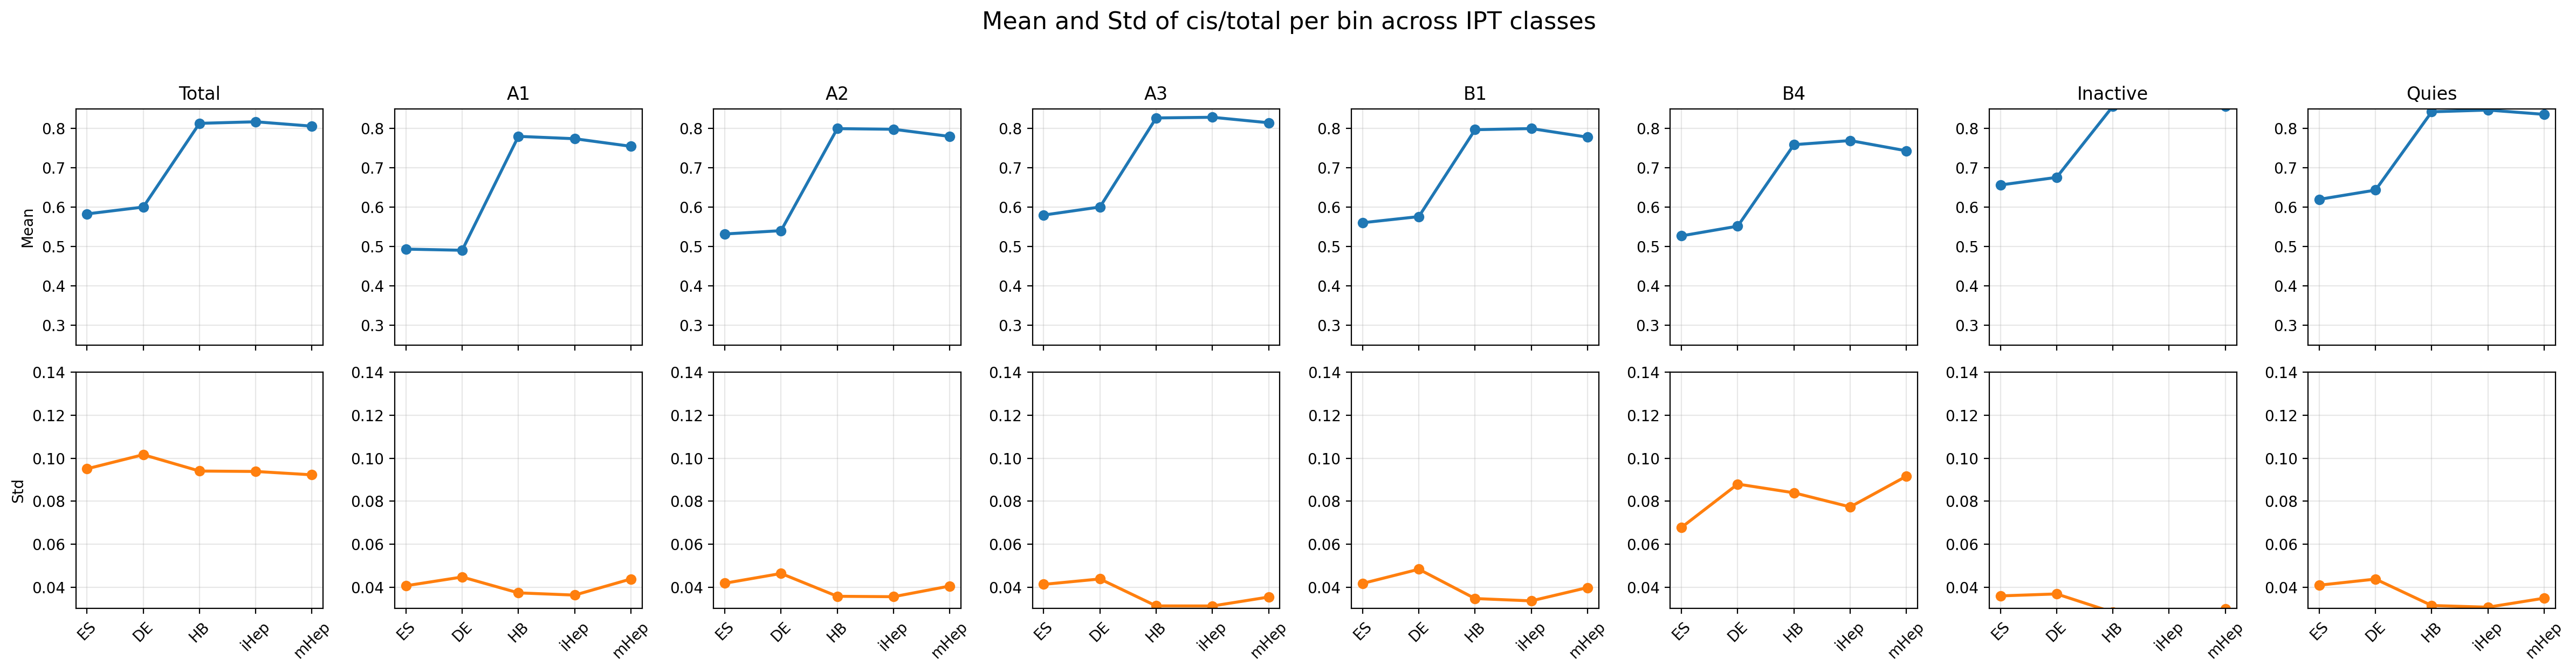

In [ ]:
# ---- settings ----
save_dir = "/home/xiangru.huo-umw/scHiC/scripts/plot"
os.makedirs(save_dir, exist_ok=True)

stage_order = ["ES", "DE", "HB", "iHep", "mHep"]
ipt_order = ["Total", "A1", "A2", "A3", "B1", "B4", "Inactive", "Quies"]

# ---- prepare ordered dataframe ----
dfp = fluctuation_df.copy()

dfp["Stage"] = pd.Categorical(
    dfp["Stage"],
    categories=stage_order,
    ordered=True
)

dfp["IPT"] = pd.Categorical(
    dfp["IPT"],
    categories=ipt_order,
    ordered=True
)

dfp = dfp.sort_values(["IPT", "Stage"])

# ---- create 8 x 2 layout ----
fig, axes = plt.subplots(
    nrows=2,
    ncols=8,
    figsize=(24, 6),
    dpi=200,
    sharex=True
)

for j, ipt in enumerate(ipt_order):

    sub = (
        dfp[dfp["IPT"] == ipt]
        .set_index("Stage")
        .reindex(stage_order)
        .reset_index()
    )

    # -----------------------------
    # Row 1: Mean
    # -----------------------------
    ax = axes[0, j]

    ax.plot(
        sub["Stage"],
        sub["Mean"],
        marker="o",
        linewidth=2,
        color="#1f77b4"
    )

    ax.set_title(ipt, fontsize=12)
    ax.set_ylabel("Mean" if j == 0 else "")
    ax.grid(alpha=0.3)

    ax.set_ylim(0.25, 0.85)

    # -----------------------------
    # Row 2: Std
    # -----------------------------
    ax = axes[1, j]

    ax.plot(
        sub["Stage"],
        sub["Std"],
        marker="o",
        linewidth=2,
        color="#ff7f0e"
    )

    ax.set_ylabel("Std" if j == 0 else "")
    ax.grid(alpha=0.3)

    ax.set_ylim(0.03, 0.14)

    # format x labels
    ax.tick_params(axis="x", rotation=45)

# global labels/title
fig.suptitle("Mean and Std of cis/total per bin across IPT classes",fontsize=16,y=1.03)

plt.tight_layout()

# ---- save ----
save_path = os.path.join(save_dir,"cis_total_fluctuation_Mean_Std_by_IPT_8x2_250kb.pdf")

plt.savefig(save_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved: {save_path}")
plt.show()